##📌 EXTRACCIÓN

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
datos = pd.read_csv('/content/TelecomX_datos_tratados (4).csv')
datos.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [4]:
datos.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7256 non-null   object 
 1   Churn             7032 non-null   object 
 2   Gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   object 
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   Tenure            7256 non-null   object 
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 


# 🛠️ Preparación de los Datos

En esta etapa se preparan los datos para su uso en modelos de Machine Learning.  
Se realizan procesos de limpieza, eliminación de columnas irrelevantes, codificación de variables categóricas y preparación del dataset para el modelado.

##🛠️ Pre procesamiento

In [6]:
datos = datos.drop(columns=['CustomerID'])

In [7]:
columnas_corregir = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for columna in columnas_corregir:
    datos[columna] = datos[columna].replace({'No internet service': 'No'})

In [8]:
datos.isnull().sum()

,0
Churn,224
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## 📊 EDA

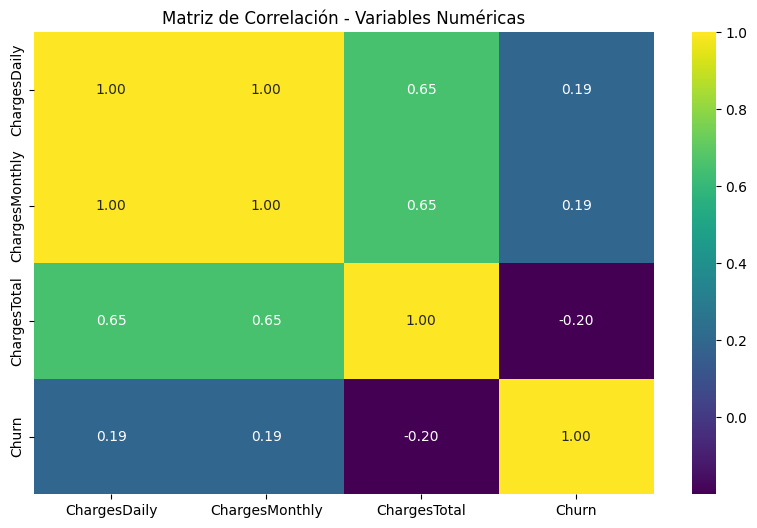

In [9]:
datos_numericos = datos.select_dtypes(include=["int64","float64"])

datos_numericos["Churn"] = datos["Churn"].map({"Yes":1,"No":0})

matriz_correlacion = datos_numericos.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="viridis",   # CAMBIO DE COLOR
    fmt=".2f"
)

plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()

In [10]:
datos = datos.drop(columns=["ChargesDaily","ChargesTotal"])

In [11]:
columnas_categoricas = datos.select_dtypes(include=["object"]).columns
columnas_categoricas = columnas_categoricas.drop("Churn")

In [12]:
for columna in columnas_categoricas:
    print(f"\n Análisis de variable: {columna}")
    display(pd.crosstab(datos[columna], datos["Churn"], normalize="index") * 100)


 Análisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565



 Análisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.349745,23.650255
Yes,58.318739,41.681261



 Análisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665



 Análisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251



 Análisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


🎯 Metodo recomendado: Qui-cuadrado (Chi-Square Test)

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crear copia
datos_rank = datos.copy()

# Convertir Churn
datos_rank["Churn"] = datos_rank["Churn"].map({"Yes":1,"No":0})

# Eliminar posibles NaN
datos_rank = datos_rank.dropna(subset=["Churn"])

# Separar variables categóricas
columnas_categoricas = datos_rank.select_dtypes(include=["object"]).columns

# Label encoding
codificador = LabelEncoder()

for columna in columnas_categoricas:
    datos_rank[columna] = codificador.fit_transform(datos_rank[columna])

# Separar X e y
X_cat = datos_rank[columnas_categoricas]
y_cat = datos_rank["Churn"]

# Test Chi-cuadrado
chi_scores, p_values = chi2(X_cat, y_cat)

# Dataframe resultados
chi_df = pd.DataFrame({
    "Variable": columnas_categoricas,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
14,Contract,1111.759054,9.186154e-244
4,Tenure,221.816756,3.631700e-50
8,OnlineSecurity,147.165601,7.219883e-34
11,TechSupport,135.439602,2.645952e-31
1,SeniorCitizen,133.482766,7.089546e-31
3,Dependents,131.271509,2.159540e-30
15,PaperlessBilling,104.979224,1.234232e-24
2,Partner,81.857769,1.462409e-19
16,PaymentMethod,59.240507,1.395318e-14
9,OnlineBackup,31.209832,2.315902e-08


In [14]:
significativas = chi_df[chi_df["p-value"] < 0.05]

print("\n Variables significativas (p < 0.05):")
display(significativas)


 Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
14,Contract,1111.759054,9.186154e-244
4,Tenure,221.816756,3.631700e-50
8,OnlineSecurity,147.165601,7.219883e-34
11,TechSupport,135.439602,2.645952e-31
1,SeniorCitizen,133.482766,7.089546e-31
3,Dependents,131.271509,2.159540e-30
15,PaperlessBilling,104.979224,1.234232e-24
2,Partner,81.857769,1.462409e-19
16,PaymentMethod,59.240507,1.395318e-14
9,OnlineBackup,31.209832,2.315902e-08


In [15]:
datos = datos.drop(columns=["Gender","PhoneService"])

Correlación

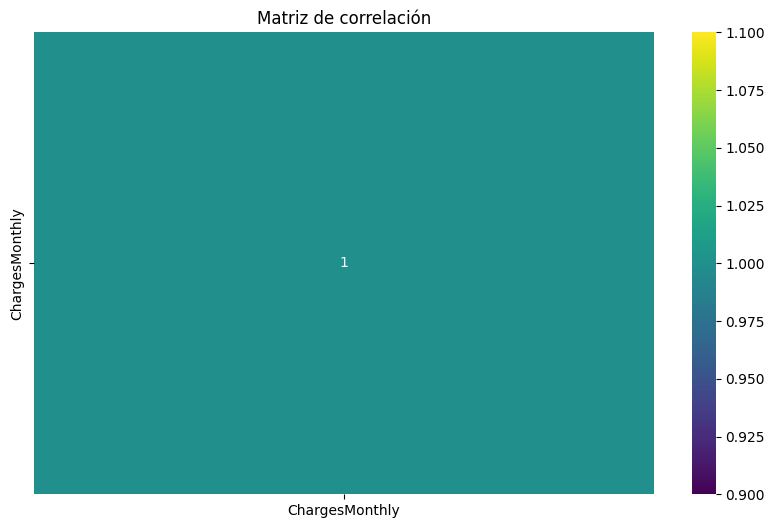

In [31]:
corr = datos.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    cmap="viridis",
    annot=True
)

plt.title("Matriz de correlación")

plt.show()

análisis dirigido

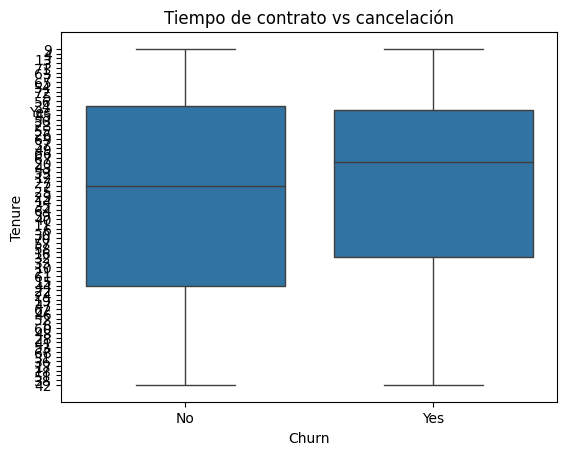

In [30]:
sns.boxplot(
    data=datos,
    x="Churn",
    y="Tenure"
)

plt.title("Tiempo de contrato vs cancelación")

plt.show()

## 🎯 Split

In [16]:
X = datos.drop("Churn",axis=1)
y = datos["Churn"]

2.Split

In [17]:
# =========================
# LIMPIEZA SEGURA
# =========================

# convertir ChargesTotal a número SOLO si existe
if "ChargesTotal" in datos.columns:
    datos["ChargesTotal"] = pd.to_numeric(datos["ChargesTotal"], errors="coerce")

# eliminar valores vacíos
datos = datos.dropna()

# =========================
# SEPARAR VARIABLES
# =========================

X = datos.drop("Churn", axis=1)
y = datos["Churn"]

# =========================
# SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# ONE HOT ENCODING
# =========================

X_entrenamiento = pd.get_dummies(X_entrenamiento, drop_first=True)
X_prueba = pd.get_dummies(X_prueba, drop_first=True)

X_entrenamiento, X_prueba = X_entrenamiento.align(
    X_prueba,
    join="left",
    axis=1,
    fill_value=0
)

3.One-Hot Encoding

In [18]:
# Aplicar one-hot encoding en entrenamiento
X_entrenamiento = pd.get_dummies(X_entrenamiento, drop_first=True)

# Aplicar en test
X_prueba = pd.get_dummies(X_prueba, drop_first=True)

# Garantizar mismas columnas
X_entrenamiento, X_prueba = X_entrenamiento.align(
    X_prueba,
    join='left',
    axis=1,
    fill_value=0
)

In [19]:
X_entrenamiento.head()

,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,Tenure_11,Tenure_12,Tenure_13,Tenure_14,Tenure_15,Tenure_16,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1456,20.35,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7215,99.55,False,True,True,False,False,False,False,False,False,...,False,True,True,True,False,True,True,False,True,False
3514,73.85,True,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4692,68.95,False,True,False,False,False,False,False,False,False,...,False,True,True,False,False,False,True,False,False,True
3706,65.20,False,True,True,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False


In [20]:
X_entrenamiento.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 1456 to 1505
Data columns (total 91 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   ChargesMonthly                         5625 non-null   float64
 1   SeniorCitizen_Yes                      5625 non-null   bool   
 2   Partner_Yes                            5625 non-null   bool   
 3   Dependents_Yes                         5625 non-null   bool   
 4   Tenure_11                              5625 non-null   bool   
 5   Tenure_12                              5625 non-null   bool   
 6   Tenure_13                              5625 non-null   bool   
 7   Tenure_14                              5625 non-null   bool   
 8   Tenure_15                              5625 non-null   bool   
 9   Tenure_16                              5625 non-null   bool   
 10  Tenure_17                              5625 non-null   bool   
 11  Tenure

4. Verificar desbalanceamiento

In [21]:
y_entrenamiento.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.422222
Yes,26.577778


##Entrenamiento


# 🤖 Modelado Predictivo

En esta sección se entrenan modelos de clasificación para predecir la cancelación de clientes.  
Se utilizan dos enfoques distintos:

- Regresión Logística
- Random Forest

La regresión logística requiere normalización debido a su sensibilidad a la escala de los datos, mientras que Random Forest no depende de la escala.

Modelo 1 — Regresion logistica

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_entrenamiento, y_entrenamiento)

predicciones_log = modelo_logistico.predict(X_prueba)

print("Regresión logística")
print(classification_report(y_prueba, predicciones_log))

Regresión logística
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Modelo 2 — Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

modelo_random = RandomForestClassifier(random_state=42)

modelo_random.fit(X_entrenamiento, y_entrenamiento)

predicciones_rf = modelo_random.predict(X_prueba)

print("Random Forest")
print(classification_report(y_prueba, predicciones_rf))

Random Forest
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1033
         Yes       0.62      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [24]:
importancias = pd.Series(
    modelo_random.feature_importances_,
    index=X_entrenamiento.columns
)

importancias.sort_values(ascending=False).head(10)

,0
ChargesMonthly,0.204593
PaymentMethod_Electronic check,0.045789
InternetService_Fiber optic,0.039576
Tenure_Yes,0.039485
Contract_Two year,0.037687
Contract_One year,0.031237
PaperlessBilling_Yes,0.030173
OnlineSecurity_Yes,0.027034
TechSupport_Yes,0.025728
Partner_Yes,0.025240


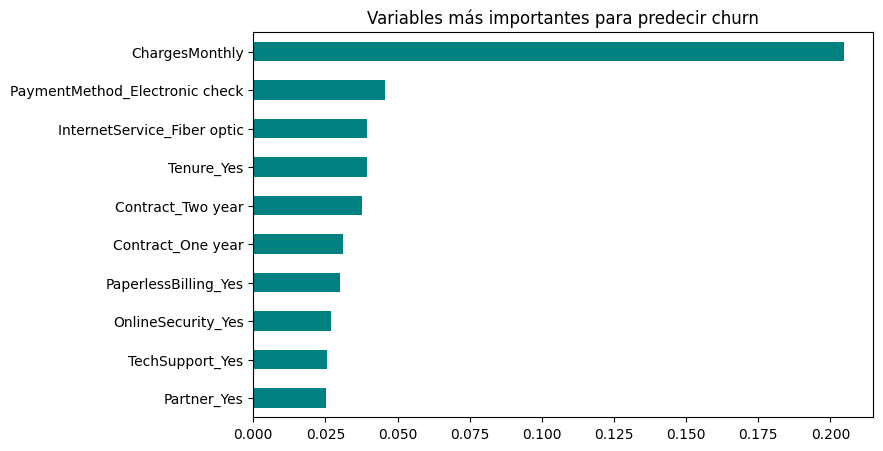

In [25]:
importancias.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,5),
    color="teal"
)

plt.title("Variables más importantes para predecir churn")

plt.show()

Regresion logistica balanceada

In [26]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000, class_weight="balanced")

modelo_logistico.fit(X_entrenamiento, y_entrenamiento)

predicciones_balanceadas = modelo_logistico.predict(X_prueba)

print(classification_report(y_prueba, predicciones_balanceadas))

              precision    recall  f1-score   support

          No       0.91      0.72      0.80      1033
         Yes       0.51      0.81      0.63       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.81      0.74      0.76      1407



##Evaluacion

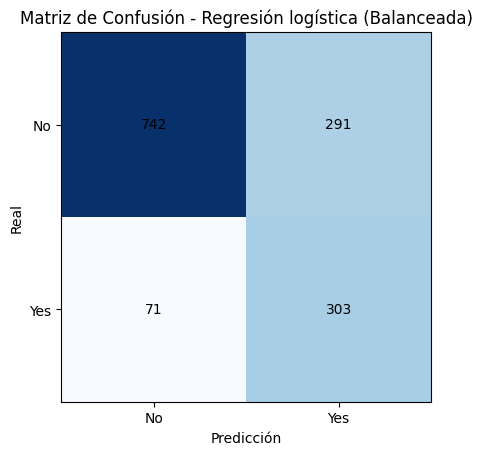

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_prueba, predicciones_balanceadas)

# Plot
plt.figure()

plt.imshow(cm, cmap="Blues")   # COLORES AZULES

plt.title("Matriz de Confusión - Regresión logística (Balanceada)")
plt.xlabel("Predicción")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No","Yes"])
plt.yticks([0,1], ["No","Yes"])

plt.show()

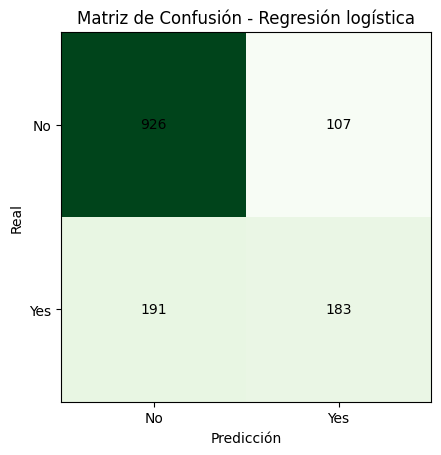

In [28]:
cm = confusion_matrix(y_prueba, predicciones_log)

plt.figure()

plt.imshow(cm, cmap="Greens")   # colores verdes

plt.title("Matriz de Confusión - Regresión logística")
plt.xlabel("Predicción")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No","Yes"])
plt.yticks([0,1], ["No","Yes"])

plt.show()

# 📋 Interpretación y Conclusiones

El análisis mostró que variables como el tiempo de contrato, el gasto mensual y el tipo de contrato influyen significativamente en la cancelación de clientes.

Los clientes con contratos mensuales presentan mayor probabilidad de churn en comparación con aquellos con contratos anuales o bianuales.

El modelo Random Forest mostró mejor desempeño general al capturar relaciones no lineales entre las variables.

## Recomendaciones

- Incentivar contratos de largo plazo  
- Implementar programas de fidelización para clientes nuevos  
- Analizar estrategias de retención para clientes con alto gasto mensual